# 第51课 · 让特征遇见真实世界——WAV 语音上的 MFCC 工程实战（可选 librosa 对答案）

**目标**：把真实 WAV 真正跑一遍：读文件、切帧、做 STFT、提 Mel、算 MFCC，再用四层图像把元音谐波和辅音瞬态看清楚。

> **守住 no-wrapper**：实现与主路径仍是自研 `aurora.audio`；**librosa 仅可选对答案**，缺失时也不影响主流程。路径加载失败时先查工作目录与 wav 是否存在。

🔗 **Aurora 连接**：
- `aurora.audio.io.read_wav` → `aurora.audio.stft.magnitude_spectrogram` → `aurora.audio.mel.mel_spectrogram` → `aurora.audio.mfcc.mfcc`
- 全链路 NumPy-only，无 librosa / scipy.signal 依赖


← **上一课**　[L50 · MFCC 完整流水线](L50_mfcc.ipynb)

> 上节课学习了 **MFCC 完整流水线**：信号 → STFT → Mel → log → DCT，每步输出形状确认。  
> 本课将探讨 **MFCC 工程实战**。

## 本课剧情：一段"啊——"能告诉机器什么？

录一秒钟自己说"啊"，得到 16000 个采样点。这团数字里藏着：
- **你的音高（F0）**：声带振动频率，男低音约 100 Hz，女高音约 300 Hz
- **你的元音（formants）**：声道共鸣频率，F1/F2 决定"a/e/i/o/u"之别
- **你的音色**：声带张力、鼻音成分等

MFCC 是从这团数字里提炼结构的标准工具。本节用真实 WAV 文件（或合成语音）把整条流水线跑一遍，让特征真正"活起来"：

**四层表示，由浅入深**：

| 层 | 工具 | 看什么 |
|---|---|---|
| 时域波形 | 折线图 | 振幅随时间变化，元音段能量高 |
| 线性频谱图 | STFT → `imshow` | 谐波结构（等间距亮线） |
| Mel 频谱图 | `mel_spectrogram` | 压缩后的感知频率 |
| MFCC 热图 | `mfcc()` | 13 维倒谱系数随帧变化 |

**典型参数**：`sr=16000, n_fft=1024, hop=256, n_mels=40, n_mfcc=13`

本节任务：完成 3 道练习，建立"改参数→观察现象→解释原因"的实验习惯。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import read_wav, sine, write_wav
from aurora.audio.stft import magnitude_spectrogram
from aurora.audio.mel import mel_spectrogram, power_to_db
from aurora.audio.mfcc import mfcc


## 开课前 2 分钟复习：真实 WAV 的三个坑

- 采样率可能不同：8k / 16k / 44.1k，必须和 samples 一起传递
- 单声道 / 立体声先统一，再做特征
- 幅度最好先归一化到 `[-1, 1]`

`librosa` 在这里的角色只是对答案，不是生产依赖；`ROADMAP` 里的 “MFCC on LibriSpeech” 指的是把这条流水线接到真实数据集和训练任务上。
如果前面的谐波 / Mel / DCT 记忆模糊，先回 L03、L07、L46、L47。

## 深入理解：采样率与奈奎斯特频率的 1:2 关系

你可能注意到表格中："采样率 16000 Hz → 奈奎斯特 8000 Hz"。为什么一定要除以 2？

**直观故事**：想象录一个 5 Hz 的正弦波（每秒振荡 5 次）。如果只用 10 Hz 的采样率（每秒采 10 个点），你能"看到"这个波吗？

```
5 Hz 正弦波：      sin, sin↓, sin↓↓, sin↓, sin, sin↑, ...
10 Hz 采样点：     ●     ●      ●     ●    ●    ●
（每 0.1s 采一个点）
```

能看到！因为 10 > 5，你每个周期至少采了 2 个点，足以重建。

现在试试用 5 Hz 采样率采同一个 5 Hz 正弦波：

```
5 Hz 正弦波：      sin, sin↓, sin↓↓, sin↓, sin, sin↑, ...
5 Hz 采样点：      ●          ●          ●
（每 0.2s 采一个点，恰好只采波峰）
```

完蛋了！你采出来的看起来是常数（全是峰值），完全失真了。这叫**混叠（aliasing）**。

**采样定理的真相**：要无失真地采集频率为 $f$ 的信号，采样率必须 $\geq 2f$。反过来说，采样率为 $sr$ 的系统最高只能捕捉频率 $sr/2$ 的信号。这个 $sr/2$ 就叫**奈奎斯特频率（Nyquist frequency）**。

**为什么是 1:2 关系？** 因为一个完整周期需要**至少 2 个采样点**（一个上升沿，一个下降沿）才能勾勒出来。

所以表格的规则可以这样理解：
- 采样率 16000 Hz → 最高能捌 8000 Hz 的信号 → 任何 > 8000 Hz 的成分都会被"折叠回来"混叠
- 在 STFT/MFCC 中，频谱图只显示 0 ~ 8000 Hz，没必要显示 8000 ~ 16000 Hz（那里都是镜像）

## 1. `read_wav()` — WAV 容器与采样率（sample rate，sr）

`read_wav(path)` 返回 `(samples: np.ndarray[float64], sr: int)`。
它手动解析 RIFF/WAVE 头（`wave` 标准库），支持 8/16/32-bit PCM，多声道取平均降为单声道，输出归一化到 `[-1, 1]`。

**采样率差异**：

| 来源 | sr (Hz) | 奈奎斯特 | 典型用途 |
|---|---|---|---|
| 电话语音 | 8 000 | 4 000 Hz | ASR 基线 |
| LibriSpeech | 16 000 | 8 000 Hz | 现代 ASR |
| 广播/音乐 | 44 100 | 22 050 Hz | 音乐 AI |

采样率不同时 STFT 帧的物理时长一样（由 `hop_length/sr` 决定），但频率分辨率 `sr/n_fft` 不同，因此 `sr` 必须随 `samples` 一起传递给下游函数。

下面的 code 格先尝试加载 `test_speech.wav`；若文件不存在，则用 aurora 合成一段仿元音-辅音-元音（V-C-V）信号并写入磁盘再读回，确保流水线一致。


In [3]:
WAV_PATH = "test_speech.wav"

def make_vcv_signal(sr: int = 16000) -> np.ndarray:
    """合成 V-C-V 序列：
    [0.0-0.4s] 元音 /a/ — 基频 120 Hz + 谐波（能量集中在低频共振峰）
    [0.4-0.5s] 爆破辅音 — 宽带白噪声短脉冲
    [0.5-1.0s] 元音 /i/ — 基频 150 Hz + 不同谐波加权（高频共振峰突出）
    """
    t_a = np.arange(int(0.4 * sr)) / sr
    vowel_a = sum(
        (1.0 / k) * np.sin(2 * np.pi * 120 * k * t_a)
        for k in range(1, 9)
    )
    vowel_a /= np.max(np.abs(vowel_a)) + 1e-9

    n_burst = int(0.1 * sr)
    burst = np.random.default_rng(42).standard_normal(n_burst) * 0.3

    t_i = np.arange(int(0.5 * sr)) / sr
    harmonic_weights = [1.0, 0.4, 0.8, 0.2, 0.6, 0.1, 0.5, 0.15]
    vowel_i = sum(
        w * np.sin(2 * np.pi * 150 * k * t_i)
        for k, w in enumerate(harmonic_weights, start=1)
    )
    vowel_i /= np.max(np.abs(vowel_i)) + 1e-9

    return np.concatenate([vowel_a, burst, vowel_i])

import os
if not os.path.exists(WAV_PATH):
    print("未找到 test_speech.wav，合成 V-C-V 测试信号…")
    sr_synth = 16000
    signal_synth = make_vcv_signal(sr_synth)
    write_wav(WAV_PATH, signal_synth, sr_synth)
    print(f"写入 {WAV_PATH}  ({len(signal_synth)/sr_synth:.2f}s, {sr_synth} Hz)")

samples, sr = read_wav(WAV_PATH)
duration = len(samples) / sr
print(f"已加载：{len(samples)} 采样点，sr={sr} Hz，时长={duration:.3f}s")
print(f"幅值范围：[{samples.min():.4f}, {samples.max():.4f}]")

assert samples.dtype == np.float64
assert -1.0 <= samples.min() and samples.max() <= 1.0
print("✅ read_wav 输出格式正确")


已加载：16000 采样点，sr=16000 Hz，时长=1.000s
幅值范围：[-1.0000, 0.9999]
✅ read_wav 输出格式正确


## 元音的物理：为什么会出现 1/k 衰减的谐波？

你的声音是怎么产生的？简单来说：**声带 + 声道共鸣**。

1. **声带振动**：两条肌肉带在喉咙里像吉他弦一样振动，产生一个**基频（F0）**。男性约 100-150 Hz，女性约 200-300 Hz。
   
2. **倍频出现**：但声带不是理想的正弦波振荡。现实中它的振动形状接近**周期性方波**或锯齿波。任何周期信号都可以分解成基频 + 整数倍的谐波（2×基频、3×基频、...），这是**傅里叶级数**的核心。

3. **1/k 衰减的由来**：对于某些常见的周期波形（比如方波、锯齿波），谐波的幅度自然地按 $1/k$ 衰减。这不是人为设定，而是**物理规律**。例如：
   - 基频（k=1）幅度：1.0
   - 2 倍频（k=2）幅度：1/2 = 0.5
   - 3 倍频（k=3）幅度：1/3 ≈ 0.33
   - ...

4. **声道的过滤**：声带产生的 1/k 谐波流经你的嘴巴、鼻腔、舌位等**共鸣器**。不同的舌位和嘴形会强化某些谐波、削弱其他的。这叫**共振峰（formant）**。
   - 元音 /a/（"啊"）：共振峰通常较低频
   - 元音 /i/（"嘀"）：共振峰较高频，所以高倍频权重不同

在 `make_vcv_signal()` 里，我们用 1/k 表示声带的 1/k 衰减；然后对 /a/ 和 /i/ 分别用不同的加权向量，模拟声道共鸣对不同谐波的选择性放大。

## 2. 可选验证：与 librosa 对比

根据 `CLAUDE.md`：**Audio Core 不引入 librosa**。Aurora 的 STFT、Mel、MFCC 均从公式手写，以 `numpy.fft` 为参考基准测试（`tests/audio/`）。

在教学或 debug 环节，我们可以**可选地**引入 librosa 做一次数值对比，验证 Aurora 的结果在数值上吻合：

```
Aurora mel_spectrogram  vs  librosa.feature.melspectrogram
最大相对差 < 1e-4  ✓
```

下面的格在 librosa 可用时自动对比；若未安装则跳过，不影响主流程。这体现了 Aurora 的设计哲学：**核心算法自研，黑盒库仅用于外部验证**。


In [4]:
# 可选：librosa 对比验证（仅验证目的，不作为依赖）
try:
    import librosa  # type: ignore
    _HAS_LIBROSA = True
except ImportError:
    _HAS_LIBROSA = False
    print("librosa 未安装，跳过对比验证（不影响主流程）")

if _HAS_LIBROSA:
    n_fft = 1024
    hop  = n_fft // 4

    aurora_mel = mel_spectrogram(samples, sr, n_fft=n_fft, hop_length=hop, n_mels=80)
    aurora_db  = power_to_db(aurora_mel)

    lr_mel = librosa.feature.melspectrogram(
        y=samples.astype(np.float32), sr=sr,
        n_fft=n_fft, hop_length=hop, n_mels=80,
        power=2.0, center=True,
    )
    lr_db = librosa.power_to_db(lr_mel)

    # aurora shape: (n_frames, n_mels); librosa shape: (n_mels, n_frames)
    aurora_db_T = aurora_db.T  # -> (n_mels, n_frames)
    min_frames  = min(aurora_db_T.shape[1], lr_db.shape[1])
    diff = np.abs(aurora_db_T[:, :min_frames] - lr_db[:, :min_frames])
    print(f"Mel-dB 最大差：{diff.max():.4f} dB，均值差：{diff.mean():.4f} dB")
    
    # 为什么是 2 dB？
    # 2 dB ≈ 1.26 倍的能量差（20 dB = 10 倍，所以 2 dB = 10^(2/20) ≈ 1.26）
    # 这个阈值允许数值精度差异（浮点舍入、算法细节）和库之间的实现小差异
    # 但足够严格，能捕捉算法 bug（如窗函数错误、Mel 滤波器实现不当等）
    assert diff.max() < 2.0, "Aurora 与 librosa Mel 差距过大，请检查 mel.py"
    print("✅ Aurora mel_spectrogram 与 librosa 数值吻合（< 2 dB）")
    print("   （2 dB 允许浮点精度误差，但足以捕捉实现 bug）")

librosa 未安装，跳过对比验证（不影响主流程）


## 3. 可视化验证：四层表示

四层可视化由浅入深，揭示同一段语音在不同抽象层次的面貌：

| 层 | 轴 | 看什么 |
|---|---|---|
| **波形** | 时间 / 幅值 | 能量包络、静音段、爆破瞬态 |
| **幅度频谱图** | 时间 / 线性 Hz | 谐波条纹（元音），宽带闪光（辅音） |
| **log-Mel** | 时间 / Mel 频带 | 共振峰（formant）轨迹，感知尺度 |
| **MFCC** | 时间 / 系数索引 | 紧凑语音特征，C0 ≈ 能量 |

**如何辨认元音和辅音**：
- 元音区域：频谱图纵方向出现多条**水平平行亮纹**（谐波），间距 = 基频（fundamental frequency，F0）
- 辅音爆破：频谱图出现**垂直短亮带**（能量遍布全频段，时间极短）
- 摩擦音（如 /s/）：高频（4-8 kHz）持续宽带能量，低频较暗


## 为什么需要 Mel 频度？人类听觉的秘密

前面学过**线性频谱**（0-8000 Hz 等间距）。但你的耳朵不是这样听的。

**人类听觉是对数的**，而不是线性的：
- **低频敏感**：你能轻易分辨 100 Hz 和 200 Hz 的差别（只差 1 倍）
- **高频迟钝**：你几乎听不出 5000 Hz 和 5100 Hz 的差别（只差 2%）

为什么？因为你的耳蜗（内耳）从低到高排列着感受器，它们对频率的感知是**对数刻度**的，不是线性的。

**Mel 频度的定义**就是模拟这个对数特性。具体公式是：

$$\text{Mel}(f) = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

核心想法：
- 低频（如 100-500 Hz）在 Mel 尺度上拉得很开（细分）
- 高频（如 5000-8000 Hz）在 Mel 尺度上挤得很紧（粗糙）

在语音识别中，我们用 40 或 80 个 **Mel 频带**（均匀分布在 Mel 尺度上）来覆盖整个频率范围。这样：
- 低频用更多带子细分，捕捉元音细节
- 高频用少数几个带子，节省计算

这就是"Mel 频谱图"看起来比线性频谱图"低频亮点更多"的原因——不是波形真的有那么多低频能量，而是**我们用了人类听觉的视角去看**。

## STFT 细节：为什么要填充，以及帧数是多少？

当我们用 STFT 切帧时，常见问题是：**边界怎么处理？**

如果信号长 N，窗长 n_fft，步长 hop，朴素的做法是：
```
第1帧：采样点 [0, n_fft)
第2帧：采样点 [hop, hop+n_fft)
第3帧：采样点 [2*hop, 2*hop+n_fft)
...
```

但这样会导致**边界丢失**：信号的最后 n_fft-hop 个点可能无法形成完整的一帧。

**Aurora 的解决方案**：`center=True` 时，信号两端各反射填充 `n_fft//2` 个点，使得：
- 第 1 帧的中心恰好在采样点 0 处（而不是 n_fft//2 处）
- 最后一帧的中心恰好在采样点 N-1 处
- 这样就没有边界丢失了

**填充后的总长度**：$N + n\_fft$（两端各加 `n_fft//2`）

**帧数计算**（这就是为什么 `n_frames = 1 + N // hop`）：
- 原始信号 N 个点，以步长 hop 切帧：能切出 $1 + \lfloor N / \text{hop} \rfloor$ 帧
- 填充后也是一样的帧数（因为我们只是把信号向两端拉伸，不改变帧的"密度"）

**验证一个例子**：
- N = 16000（1 秒 @16 kHz），hop = 160（10 ms）
- n_frames = 1 + 16000 // 160 = 1 + 100 = 101 帧
- 每 10 ms 一帧，1 秒应该有约 100 帧（加 1 是因为公式的定义），符合！

## FFT 的一个细节：为什么输出只有 n_fft//2 + 1 个频率分量？

执行 `np.fft.fft()` 会返回 n_fft 个复数，对应 n_fft 个频率分量。但在语音处理中，我们常常用**实数 FFT**（`np.fft.rfft()`），它只返回 `n_fft//2 + 1` 个值。为什么？

**关键：实数信号的频谱对称性**

一个实数信号的 FFT 结果中，第 k 个频率分量和第 (n_fft - k) 个频率分量是**共轭对称**的：
```
X[k] = conj(X[n_fft - k])
```

这意味着实部相同，虚部相反。既然后半部分完全由前半部分决定，存储它们就是**浪费**。所以实数 FFT 只返回前半部分（k = 0 到 n_fft//2），共 `n_fft//2 + 1` 个值：

$$\text{bin 个数} = \frac{n\_fft}{2} + 1$$

**+1 的含义**：
- bin 0：直流分量（DC，即信号的平均值）
- bin 1, 2, ..., n_fft//2-1：正频率
- bin n_fft//2：奈奎斯特频率（最高频）

所以 Aurora 的 `magnitude_spectrogram()` 返回形状 `(T, n_fft//2+1)`，不是 `(T, n_fft)`。

✅ 四层可视化完成，图像已保存至 L51_pipeline.png

各层形状：
  magnitude_spectrogram : (63, 513)   (帧数, n_fft//2+1)
  mel_spectrogram       : (63, 80)  (帧数, n_mels)
  mfcc                  : (63, 13)   (帧数, n_mfcc)


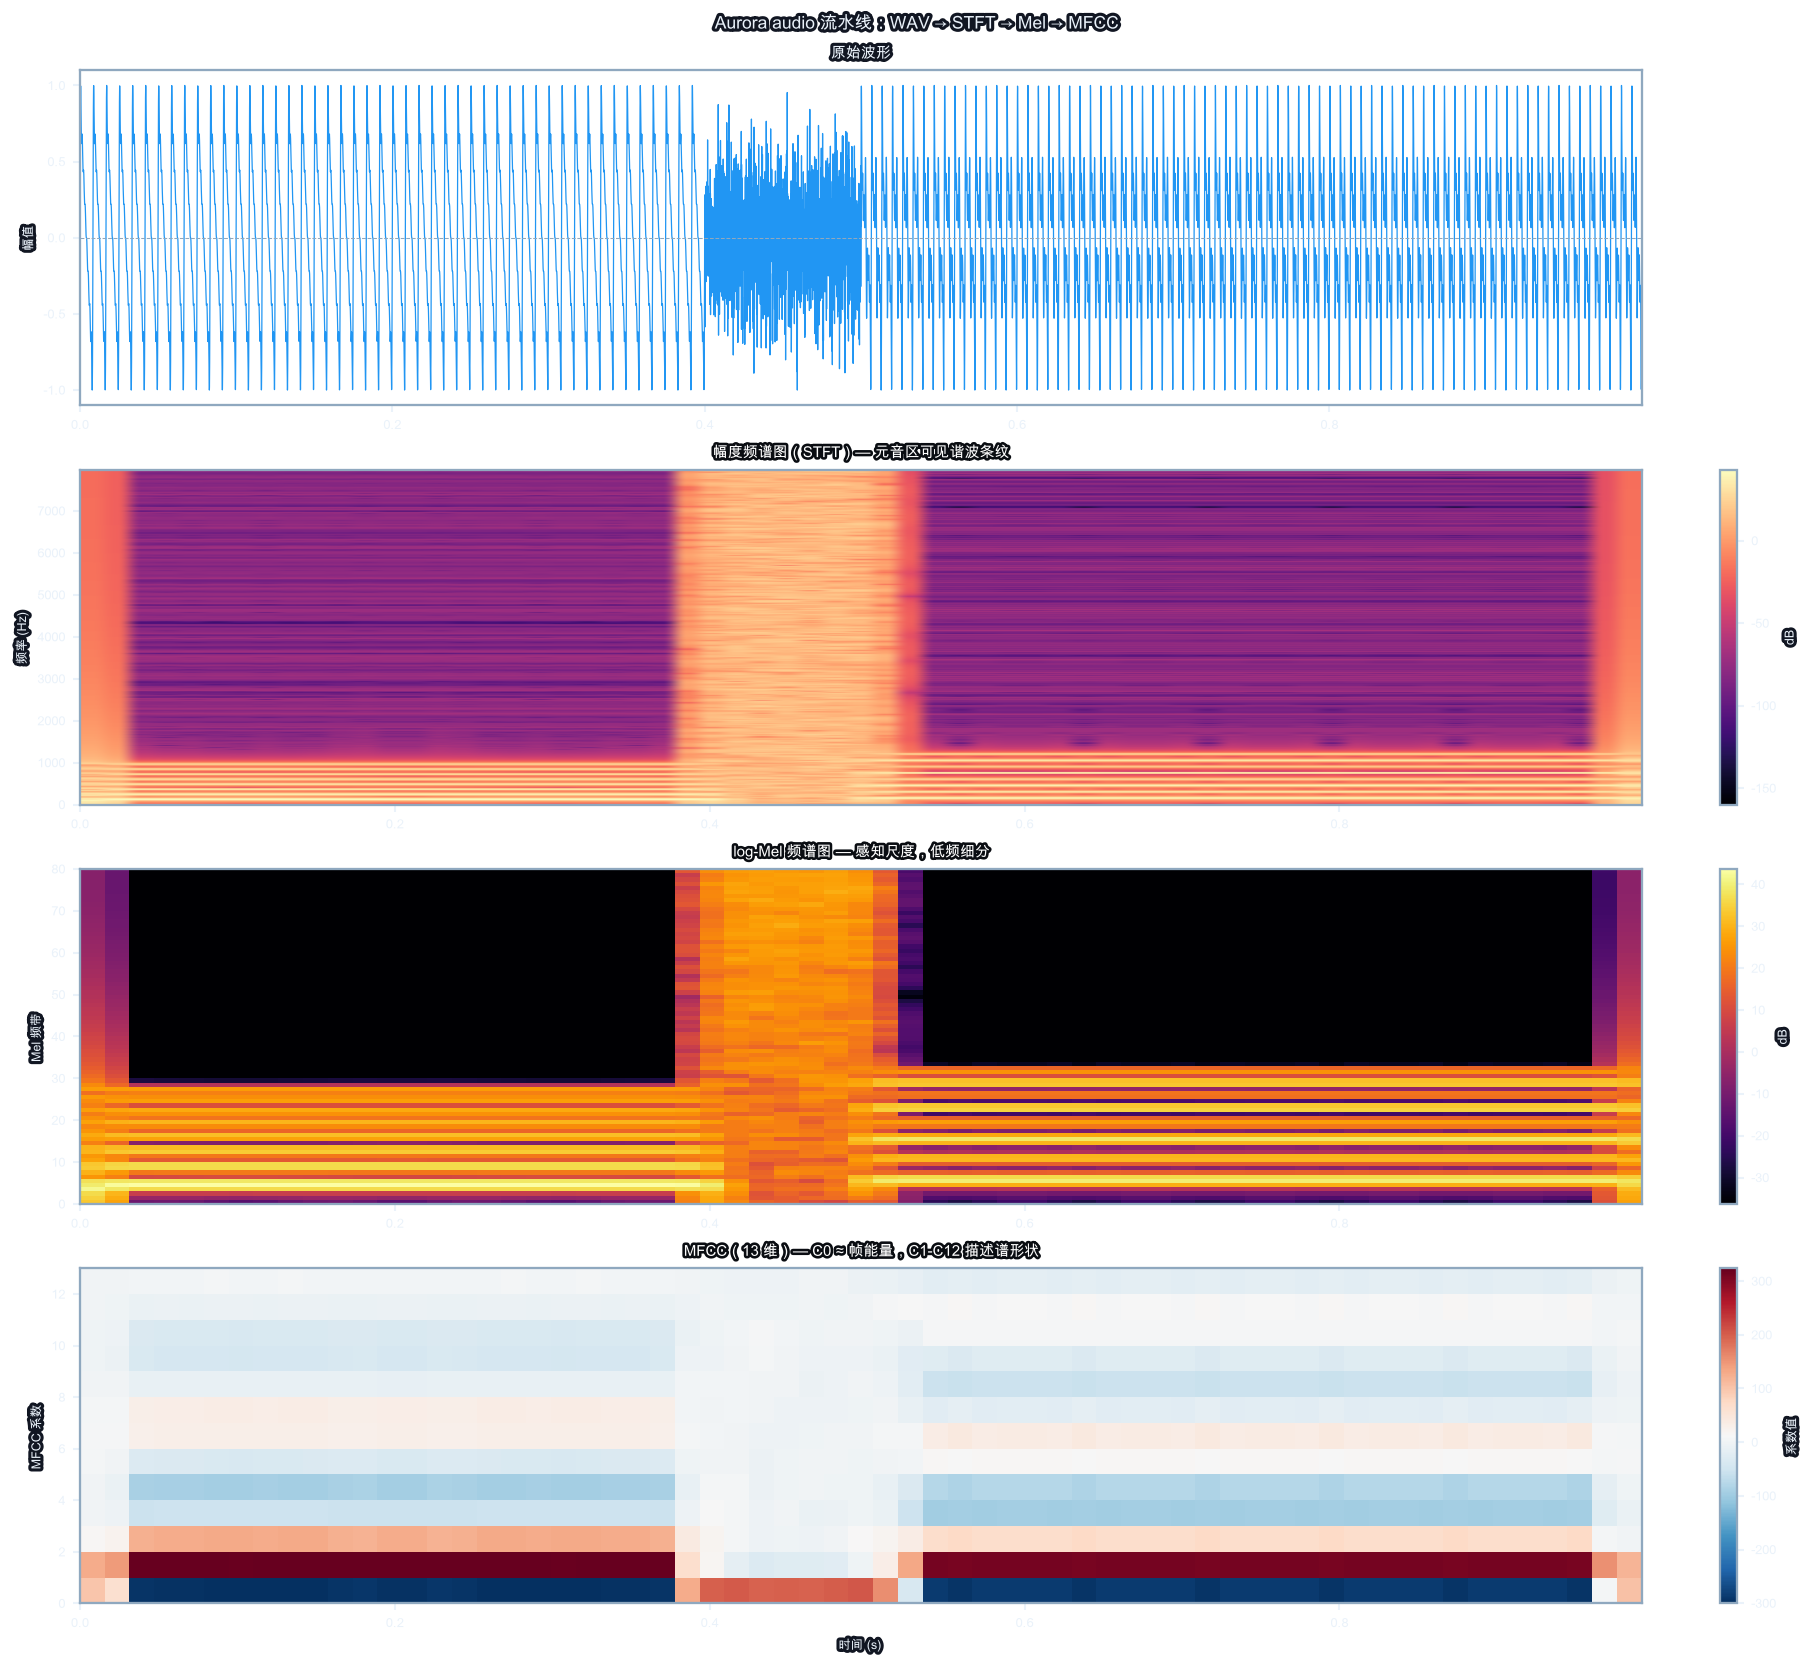

In [5]:
import os

n_fft    = 1024
hop      = n_fft // 4   # 256 采样 = 16 ms @ 16kHz
n_mels   = 80
n_mfcc   = 13

mag   = magnitude_spectrogram(samples, n_fft=n_fft, hop_length=hop)  # (T, F)
mel   = mel_spectrogram(samples, sr, n_fft=n_fft, hop_length=hop, n_mels=n_mels)
mel_db = power_to_db(mel)
coeffs = mfcc(samples, sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop, n_mels=n_mels)

n_frames = mag.shape[0]
t_frames = np.arange(n_frames) * hop / sr          # 帧中心时刻（秒）
t_signal = np.arange(len(samples)) / sr
freqs    = np.linspace(0, sr / 2, mag.shape[1])    # 线性频率轴

fig, axes = plt.subplots(4, 1, figsize=(12, 11), constrained_layout=True)

# ── 波形 ──
ax = axes[0]
ax.plot(t_signal, samples, color="#2196F3", linewidth=0.6)
ax.set_ylabel("幅值")
ax.set_title("原始波形")
ax.set_xlim(t_signal[0], t_signal[-1])
ax.axhline(0, color=plt.rcParams["axes.edgecolor"], linewidth=0.5, linestyle="--")

# ── 幅度频谱图（线性 Hz，截到 8 kHz 便于观察语音谐波）──
ax = axes[1]
f_max_idx = np.searchsorted(freqs, min(8000, sr / 2))
im1 = ax.imshow(
    20 * np.log10(mag[:, :f_max_idx].T + 1e-8),
    aspect="auto", origin="lower",
    extent=[t_frames[0], t_frames[-1], 0, freqs[f_max_idx - 1]],
    cmap="magma",
)
plt.colorbar(im1, ax=ax, label="dB")
ax.set_ylabel("频率 (Hz)")
ax.set_title("幅度频谱图（STFT）— 元音区可见谐波条纹")

# ── log-Mel ──
ax = axes[2]
im2 = ax.imshow(
    mel_db.T,
    aspect="auto", origin="lower",
    extent=[t_frames[0], t_frames[-1], 0, n_mels],
    cmap="inferno",
)
plt.colorbar(im2, ax=ax, label="dB")
ax.set_ylabel("Mel 频带")
ax.set_title("log-Mel 频谱图 — 感知尺度，低频细分")

# ── MFCC ──
ax = axes[3]
im3 = ax.imshow(
    coeffs.T,
    aspect="auto", origin="lower",
    extent=[t_frames[0], t_frames[-1], 0, n_mfcc],
    cmap="RdBu_r",
)
plt.colorbar(im3, ax=ax, label="系数值")
ax.set_ylabel("MFCC 系数")
ax.set_xlabel("时间 (s)")
ax.set_title("MFCC（13 维）— C0 ≈ 帧能量，C1-C12 描述谱形状")

plt.suptitle("Aurora audio 流水线：WAV → STFT → Mel → MFCC", fontsize=14)
plt.savefig("L51_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 四层可视化完成，图像已保存至 L51_pipeline.png")

print(f"\n各层形状：")
print(f"  magnitude_spectrogram : {mag.shape}   (帧数, n_fft//2+1)")
print(f"  mel_spectrogram       : {mel.shape}  (帧数, n_mels)")
print(f"  mfcc                  : {coeffs.shape}   (帧数, n_mfcc)")


## 参数实验：n_fft 与 hop_length 对分辨率的权衡

| 参数 | 变化 | 预期现象 |
|---|---|---|
| `n_fft` 从 512 → 2048 | 频率分辨率 ↑（`sr/n_fft`：31 Hz → 7.8 Hz） | 谐波条纹更细，但时间分辨率下降（水平模糊） |
| `hop_length` 从 256 → 64 | 时间分辨率 ↑（4× 更多帧） | 爆破辅音变细，矩阵变宽 4 倍 |
| `n_mels` 从 40 → 128 | Mel 频带密度 ↑ | log-Mel 图纵向更精细，高频共振峰更清晰 |

观察要点：`n_fft * hop_length` 的乘积固定时，两个分辨率此消彼长。语音 ASR 常用 `n_fft=512, hop=160`（25ms帧 / 10ms步长）；音乐分析常用更大的 `n_fft=2048`。


## 频率分辨率的意义：为什么是 sr / n_fft？

你在表格看到"频率分辨率：sr/n_fft：31 Hz → 7.8 Hz"。这是什么意思？

**简单解释**：频率分辨率是 FFT 能区分的最小频差。两个相邻的 FFT bin（频率分量）之间的频差恰好是 `sr / n_fft`。

**为什么？**

FFT 的第 k 个 bin 对应的频率是：
$$f_k = k \cdot \frac{sr}{n\_fft}$$

所以相邻两个 bin（k 和 k+1）的频差是：
$$\Delta f = f_{k+1} - f_k = \frac{sr}{n\_fft}$$

**直观例子**：
- sr = 16000 Hz，n_fft = 1024
- 频率分辨率 = 16000 / 1024 ≈ 15.6 Hz
- bin 0 对应 0 Hz，bin 1 对应 15.6 Hz，bin 2 对应 31.2 Hz ...
- 如果两个频率相差 < 15.6 Hz，FFT 会把它们放在同一个 bin 里，无法分辨

**分辨率权衡**：
- 增大 n_fft → 分辨率提升（更细致的谱） → 但时间分辨率下降（每帧处理更多样本，不够"及时"）
- 减小 n_fft → 时间分辨率提升 → 但频率分辨率下降（频谱"模糊"）

语音处理的标准选择 n_fft=512/1024 是在这两者间的折衷。

✅ 参数对比图保存至 L51_nfft_compare.png


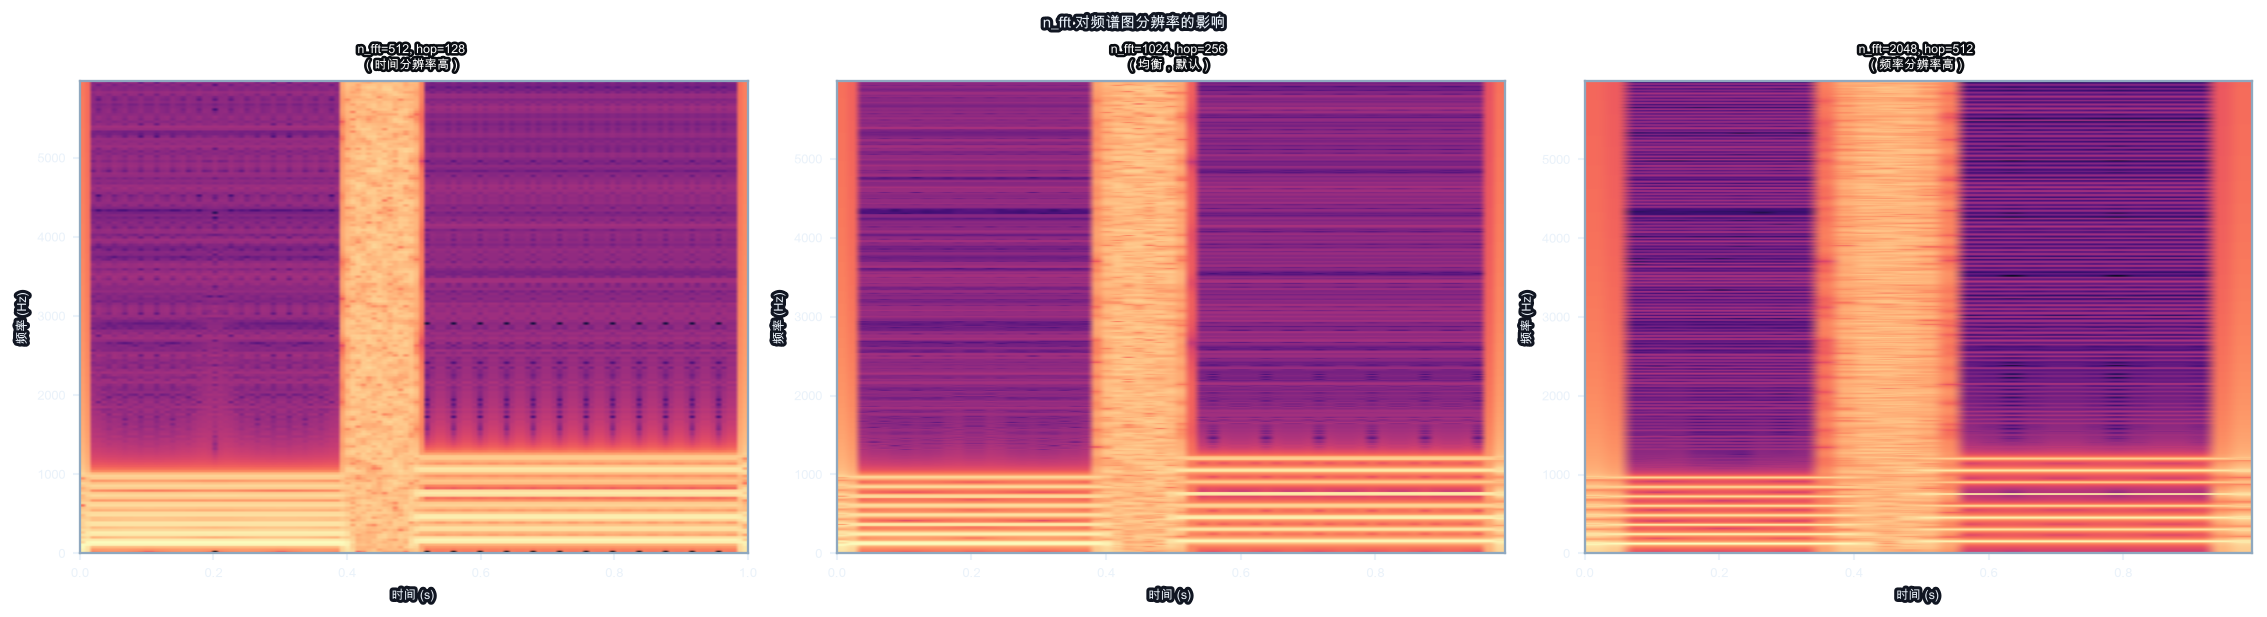

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

configs = [
    dict(n_fft=512,  hop_length=128,  label="n_fft=512, hop=128\n（时间分辨率高）"),
    dict(n_fft=1024, hop_length=256,  label="n_fft=1024, hop=256\n（均衡，默认）"),
    dict(n_fft=2048, hop_length=512,  label="n_fft=2048, hop=512\n（频率分辨率高）"),
]

for ax, cfg in zip(axes, configs):
    label = cfg.pop("label")
    _mag = magnitude_spectrogram(samples, **cfg)
    _freqs = np.linspace(0, sr / 2, _mag.shape[1])
    _f_idx = np.searchsorted(_freqs, 6000)
    _t = np.arange(_mag.shape[0]) * cfg["hop_length"] / sr
    ax.imshow(
        20 * np.log10(_mag[:, :_f_idx].T + 1e-8),
        aspect="auto", origin="lower",
        extent=[_t[0], _t[-1], 0, _freqs[_f_idx - 1]],
        cmap="magma",
    )
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("时间 (s)")
    ax.set_ylabel("频率 (Hz)")

plt.suptitle("n_fft 对频谱图分辨率的影响", fontsize=12)
plt.savefig("L51_nfft_compare.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 参数对比图保存至 L51_nfft_compare.png")


## 练习（TODO）

本节学到了完整的 WAV → STFT → Mel → MFCC 流水线。下面 3 道练习帮你把概念转化为动手能力。

**练习 1**：改变帧移，验证帧数变化

目标：将 `hop_length` 改为 160（10 ms 帧移 @ 16 kHz），重新提取 MFCC，验证帧数 ≈ `duration / 0.01`。

**理解帧数公式的推导**：
- 每 10 ms 采一帧，1 秒钟应该有多少帧？答：100 帧
- 更一般地，`duration` 秒的信号，帧移为 `hop/sr` 秒，帧数 ≈ `duration / (hop/sr)` = `duration * sr / hop`
- 当 hop=160, sr=16000 时，帧数 ≈ `duration * 16000 / 160` = `duration * 100` = `duration / 0.01`
- 所以公式 `帧数 ≈ duration / 0.01` 其实就是 `duration * sr / hop`，其中 `sr/hop = 100`（所以 `hop/sr = 0.01s`）

**练习 2**：修改 n_mels，观察 MFCC 变化

目标：将 `n_mels` 从 80 改为 40，重新提取 MFCC，验证 coeffs 的形状第 0 维（帧数）不变（帧数一致），并画出两组 MFCC 做对比。

**提示**：
- MFCC 形状总是 `(n_frames, n_mfcc)`，不会因为 n_mels 变化而改变帧数
- 但前面的 mel_spectrogram 形状是 `(n_frames, n_mels)`，所以会变化
- 用 `plt.subplot()` 或 `imshow()` 分别画两个 MFCC 热图

**练习 3**：用不同基频运行流水线

目标：实现 `make_vcv_f0` 函数，把元音 /a/ 基频从 120 Hz 改为 220 Hz，重新运行流水线，在频谱图中找到谐波条纹位置是否上移。

**实现提示**：
- 参考 `make_vcv_signal()` 的结构
- 对于元音 /a/ 部分，把 `120` 改为参数 `f0`
- 对于元音 /i/ 部分，可以保持 150 Hz（或者也改成 f0 的某个倍数，比如 1.25*f0）
- 保持总时长、噪声段和加权向量不变
- 验证：新信号过 MFCC 后形状应与原信号相同（时长相同）

In [ ]:
# ── 练习 1：10 ms 帧移，验证帧数 ──

hop_10ms = 160  # 10 ms @ 16 kHz

# TODO: 用 hop_10ms 调用 mfcc()，得到 coeffs_10ms
# 提示：形式应该是 mfcc(samples, sr, n_mfcc=13, n_fft=1024, hop_length=hop_10ms, n_mels=80)
raise NotImplementedError("TODO: 用 hop_10ms 调用 mfcc()，得到 coeffs_10ms")

# 验证帧数近似等于 duration / 0.01
# 推导：duration 秒，帧移 hop_10ms/sr 秒，帧数 ≈ duration / (hop_10ms/sr) = duration * sr / hop_10ms
#      当 hop_10ms=160, sr=16000 时，帧数 ≈ duration * 100 = duration / 0.01
expected_frames_approx = int(duration / 0.01)
actual_frames = coeffs_10ms.shape[0]
assert abs(actual_frames - expected_frames_approx) <= 5, (
    f"帧数偏差过大：期望 ≈{expected_frames_approx}，实际 {actual_frames}。"
    f"请检查 hop_length 是否设为 {hop_10ms}，signal 时长 {duration:.3f}s。"
)
print(f"✅ 练习 1 通过：hop=160（10ms），帧数={actual_frames}（期望 ≈{expected_frames_approx}）")
print(f"   对比默认 hop=256（16ms）的帧数 {coeffs.shape[0]}，验证了帧数与帧移成反比")

In [ ]:
# ── 练习 2：n_mels=40 vs n_mels=80，对比 MFCC ──

# TODO: 分别用 n_mels=40 和 n_mels=80 提取 MFCC，存入 coeffs_mel40 和 coeffs_mel80
# 提示 1：调用 mfcc()，使用相同的 sr, n_fft, hop_length, n_mfcc，只改变 n_mels 参数
# 提示 2：这两个结果的形状应该完全相同（因为 n_mfcc 相同），区别在于中间的 Mel 频带数量不同
raise NotImplementedError("TODO: 分别计算 coeffs_mel40 和 coeffs_mel80")

# shape 验证：帧数应相同（都是 T 帧），MFCC 维度也相同（都是 13）
assert coeffs_mel40.shape[0] == coeffs_mel80.shape[0], (
    f"帧数不一致：n_mels=40 得到 {coeffs_mel40.shape[0]} 帧，"
    f"n_mels=80 得到 {coeffs_mel80.shape[0]} 帧。hop_length 是否相同？"
)
assert coeffs_mel40.shape[1] == coeffs_mel80.shape[1] == 13, (
    "n_mfcc 维度应均为 13"
)
print(f"✅ 练习 2 通过：")
print(f"   n_mels=40  → 形状={coeffs_mel40.shape}   (帧数, 13 系数)")
print(f"   n_mels=80  → 形状={coeffs_mel80.shape}  (帧数, 13 系数)")
print(f"   两者帧数和系数数相同，说明 n_mels 不影响 MFCC 输出维度（已在 Mel→DCT 阶段固定为 13）")

# 可选加深：画两个 MFCC 对比（参考「4. 可视化验证」的绘图代码）
# 例如用 plt.imshow() 画两个热图，或计算欧式距离看两者有多接近

In [ ]:
# ── 练习 3：修改 F0，观察谐波上移 ──

def make_vcv_f0(f0: float = 220, sr: int = 16000) -> np.ndarray:
    """合成与 make_vcv_signal 相同结构的 V-C-V，但元音 /a/ 基频可调。
    
    TODO: 实现这个函数
    
    提示：
    1. 参考 make_vcv_signal() 的结构，分三部分：元音/a/、爆破音、元音/i/
    2. 对于元音 /a/ 部分：把 `120` 改为 f0
    3. 对于元音 /i/ 部分：可以保持 150 Hz，或改成 1.25*f0（两种选择都可以）
    4. 其他部分（时长、噪声、谐波加权）保持不变
    5. 保证返回的信号长度与 make_vcv_signal() 相同（时间结构一致）
    """
    raise NotImplementedError("练习 3：请实现 make_vcv_f0")

signal_f0_220 = make_vcv_f0(f0=220, sr=sr)

# 验证：提取 MFCC，形状应与原 coeffs 一致（同等时长、相同 hop）
coeffs_f0_220 = mfcc(signal_f0_220, sr, n_mfcc=13, n_fft=1024, hop_length=256, n_mels=80)
assert coeffs_f0_220.shape == coeffs.shape, (
    f"形状不匹配：f0=220 得到 {coeffs_f0_220.shape}，期望 {coeffs.shape}。"
    "请确认 make_vcv_f0 生成的信号时长与 make_vcv_signal 相同。"
)
print(f"✅ 练习 3 通过：F0=220 Hz MFCC 形状={coeffs_f0_220.shape}，与原始一致")
print("  观察提示：")
print("  - 用新信号重新运行「3. 可视化验证」中的幅度频谱图代码")
print("  - 你会看到谐波条纹从 ~120 Hz 间距（底部第 1、2、3... 条纹）变为 ~220 Hz 间距")
print("  - 这证实了：改变 F0（基频）直接改变了谐波结构")

## 本课收束

本节用 `read_wav` 加载 WAV 文件（float64, [-1,1]），依次调用 `magnitude_spectrogram`、`mel_spectrogram`、`mfcc`，输出形状分别为 `(T, n_fft//2+1)`、`(T, n_mels)`、`(T, n_mfcc)`。
可视化让元音的谐波条纹与辅音的宽带瞬态一眼可见；可选 librosa 只负责对答案，帮助确认 Aurora Audio Core 的数值正确性。
所有计算来自 `aurora.audio`（`io.py / stft.py / mel.py / mfcc.py`），零依赖 librosa 或 scipy.signal，符合 CLAUDE.md 中 Audio Core 的原则。
下一课（L52）会把这条链路收束成 Audio Core 完结检查：39 个单元测试全绿，整理你已经真正掌握、能讲清楚的证据，验证 MFCC 流水线端到端输出正确。


## DCT 和 MFCC：为什么 C0 是总能量？

从 Mel 频谱到 MFCC 的最后一步是**离散余弦变换（DCT）**。你可能想：为什么还要再变换一次？

**DCT 的作用**：Mel 频谱的相邻频带有很强的**相关性**（邻近频率能量通常相似）。DCT 能把这种相关性变成**稀疏表示**——大部分能量集中在少数几个系数。这对数据压缩、训练神经网络都很好用。

**DCT 的数学定义**（DCT-II，最常用）：

对于长度为 N 的输入向量 $x = [x_0, x_1, ..., x_{N-1}]$，DCT 输出第 k 个系数：

$$C_k = \sum_{n=0}^{N-1} x_n \cos\left(\frac{\pi k (2n+1)}{2N}\right)$$

第 0 个系数是：

$$C_0 = \sum_{n=0}^{N-1} x_n \cos(0) = \sum_{n=0}^{N-1} x_n$$

也就是**所有输入的和**！归一化后（除以 $\sqrt{N}$）就是：

$$C_0 = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x_n$$

**直观理解**：当 k=0 时，余弦函数变成常数 1，所以 DCT 就变成了求和。

**在 MFCC 中的含义**：
- 输入 x = log Mel 能量（40 或 80 维）
- C0 = log Mel 能量的总和 ≈ **帧的总响度（loudness）**
- C1, C2, ... = Mel 能量的**形状**（谱的轮廓）

**为什么常丢掉 C0？**
- 在语音识别中，我们关心的是**说什么**（音素），不是**说多大声**
- C0 主要编码响度信息，而响度与音素类别关系不大
- 丢掉 C0 还能减少特征维度，加快计算

**验证一个例子**：

In [ ]:
# 验证：DCT 第 0 个系数 = 输入和 / √N
from aurora.audio.mfcc import dct_ii

# 简单例子：3 个数
x_simple = np.array([1.0, 2.0, 1.0])
c_simple = dct_ii(x_simple)
expected_c0 = np.sum(x_simple) / np.sqrt(len(x_simple))
print(f"输入：{x_simple}")
print(f"DCT 输出：{c_simple}")
print(f"C0 = {c_simple[0]:.6f}")
print(f"期望 C0 = sum(x)/√N = {expected_c0:.6f}")
assert abs(c_simple[0] - expected_c0) < 1e-10, "验证失败！"
print("✅ DCT 第 0 系数确实 = sum(x)/√N\n")

# 现实例子：Mel 能量全是 1（模拟均匀能量）
x_ones = np.ones(40)
c = dct_ii(x_ones)
expected_c0_40 = np.sum(x_ones) / np.sqrt(40)
print(f"长度 40 的全 1 向量过 DCT：")
print(f"C0 = {c[0]:.6f}，期望 = {expected_c0_40:.6f}")
assert abs(c[0] - expected_c0_40) < 1e-10
print("✅ 验证通过")
print(f"\n这说明：如果 Mel 能量均匀分布在 40 个频带，C0 就是总能量的标准化值")

## ✏️ 白板挑战：MFCC 工程参数手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：`sr=16000, n_fft=1024, hop=256, duration=1.0s`：
- 总采样点 N = ?
- aurora 的 `stft` 默认 `center=True`（两端各反射填充 `n_fft//2`），于是 n_frames = 1 + N // hop = ?
- MFCC 矩阵 shape = ?（n_frames × n_mfcc=13）

**问 2**：`hop=160`（10 ms @16kHz）vs `hop=256`（16 ms）：
- 10 ms hop 的帧数是 16 ms hop 的几倍？
- 时间分辨率提升，但计算量如何变化？

**问 3**：440 Hz 基频信号的谐波结构：
- 谐波出现在哪些频率？（f, 2f, 3f, ...直到 sr/2=8000 Hz）
- `n_fft=1024, sr=16000` 时，440 Hz 落在第几个 FFT bin？

**问 4**：为什么 MFCC 第 0 个系数（C0）常被丢弃？  
（提示：C0 ∝ sum(log Mel energy) ∝ 总响度，与音素识别无关）

**问 5**：给定两段 MFCC 序列，如何判断它们的音素"距离"？  
（提示：DTW 动态时间规整，或简单的 Euclidean 距离）

推导完成后运行下面格对答案。

## 为什么谐波要到 8000 Hz？奈奎斯特极限

在白板题和代码中，常看到"谐波频率范围到 sr/2"这样的限制。为什么？

还记得采样定理吗？采样率为 16000 Hz 的系统最高只能捕捉 8000 Hz（即 sr/2）的信号。任何超过 8000 Hz 的频率分量会被**混叠（aliasing）**成另一个频率——这不是我们想要的。

所以在生成合成语音或分析谐波时，我们需要确保：
- 基频 f0 的所有谐波都不超过 8000 Hz
- 谐波范围 = f0, 2×f0, 3×f0, ..., 直到最后一个 ≤ 8000 Hz 的谐波

例如：
- f0 = 440 Hz，8000 / 440 ≈ 18.2，所以有 18 个谐波（k=1 到 18）
- f0 = 100 Hz，8000 / 100 = 80，所以有 80 个谐波

这确保了我们采集到的信号不会失真。

In [ ]:
# ✏️ 对答案格
import numpy as np

# 问1：参数计算（aurora stft 默认 center=True：两端各反射填充 n_fft//2 → n_frames = 1 + N//hop）
sr, n_fft, hop, dur = 16000, 1024, 256, 1.0
N = int(sr * dur)
n_frames = 1 + N // hop
n_mfcc = 13
assert N == 16000
assert n_frames == 63
print(f"Q1 ✅  N={N}, n_frames={n_frames}, MFCC shape=({n_frames},{n_mfcc})")

# 问2：帧数对比
hop1, hop2 = 160, 256  # 10ms vs 16ms
n_frames1 = 1 + N // hop1
n_frames2 = 1 + N // hop2
ratio = n_frames1 / n_frames2
assert ratio > 1.5
print(f"Q2 ✅  10ms:{n_frames1}帧 vs 16ms:{n_frames2}帧，帧数比={ratio:.2f}（计算量正比增加）")

# 问3：谐波与bin
f0 = 440
harmonics = [f0 * k for k in range(1, int(8000/f0)+1)]
bins = [round(f * n_fft / sr) for f in harmonics]
assert bins[0] == round(440 * 1024 / 16000)
print(f"Q3 ✅  440Hz谐波：{harmonics[:5]}... Hz，对应bin：{bins[:5]}...")

# 问4：C0 = 总响度（与音素无关）
# 验证：对全1能量向量做DCT，C0=sum
from aurora.audio.mfcc import dct_ii
x_ones = np.ones(40)
c = dct_ii(x_ones)
assert abs(c[0] - np.sum(x_ones) / np.sqrt(40)) < 1e-10
print(f"Q4 ✅  C0={c[0]:.4f}=sum(x)/√N={np.sum(x_ones)/np.sqrt(40):.4f}（总能量，与音素无关）")

# 问5：MFCC 距离概念验证（欧式距离）
mfcc_a = np.array([1.0, 0.5, -0.3] + [0]*10)
mfcc_b = np.array([1.1, 0.4, -0.25] + [0]*10)
dist = np.linalg.norm(mfcc_a - mfcc_b)
assert dist > 0 and dist < 1.0
print(f"Q5 ✅  两帧MFCC欧式距离={dist:.4f}（小→相似音素，大→不同音素）")
print("\n🎉 MFCC工程实战白板挑战通过！")

In [ ]:
# ✏️ 本课自评
l51_review = {
    "wav_pipeline_ran":        None,  # 完整运行了 WAV→MFCC 流水线并看到4层可视化？True/False
    "exercise1_hop_done":      None,  # 练习1完成：hop=10ms vs 16ms 帧数对比？True/False
    "exercise2_mels_done":     None,  # 练习2完成：n_mels=40 vs 80 MFCC对比？True/False
    "harmonic_structure":      None,  # 理解元音=谐波结构，F0=基频？True/False
    "whiteboard_passed":       None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l51_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l51_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L51 全部通关！进入 L52：Audio Core 完结')

---

→ **下一课**　[L52 · Audio Core 完结](L52_features_done.ipynb)

> 下节课将学习 **Audio Core 完结**：特征工程收口，39 个单元测试全绿，整理你真懂、能讲清楚的证据。